---
title: "3. Acoustics"
subtitle: The physics of sound, rooms, and instruments
---

This week is about *acoustics*, a term everyone knows yet few can define properly. We will go through the physics of sound and then look more closely at instrument acoustics and room acoustics.

```{note}
**Levels reminder:** This chapter is mainly about the *physical* signal—waves in a medium, sources, and rooms—before [digital representation](electroacoustics.ipynb), [perception](psychoacoustics.ipynb), and [interpretation](the-brain.ipynb) are treated in depth elsewhere. For the full four-level overview (physics → DSP → perception → cognition and emotion), see [Tuning in](tuning-in.ipynb).
```

## Defining acoustics

Acoustics is the study of sound and its properties. The term comes from the Greek *ἀκουστικός (akoustikos)*, meaning "of or for hearing, ready to hear." According to the American National Standard on acoustical terminology {cite:p}`ANSI_ASA_S1_1_2013`, acoustics has two meanings:

1. The science of sound, encompassing its production, transmission, and effects, both biological and psychological ([acoustics](https://en.wikipedia.org/wiki/Acoustics))
2. The qualities of a room that determine its auditory characteristics (the sub-discipline of [room acoustics](https://en.wikipedia.org/wiki/Room_acoustics)).

We will begin with acoustics broadly and then turn to some of its subdisciplines: room acoustics, instrument acoustics, and electroacoustics. These are only a few of the many subdisciplines, as the overview below shows.

```{image} figures/external/acoustics/03-Lindsay-s-Wheel-of-Acoustics.svg
:alt: Lindsay's Wheel of Acoustics
:width: 100%
```

*Figure: Lindsay's Wheel of Acoustics, illustrating the interdisciplinary nature of acoustics ([source](https://commons.wikimedia.org/wiki/File:Lindsay%27s_Wheel_of_Acoustics.svg)).*

### Why acoustics matters for musicology, music psychology, and music technology

Acoustics gives all three fields their scientific footing for how sound is produced, transmitted, and perceived. In musicology, it helps us analyse the physical properties of instruments and performance spaces, which feeds into historical and cultural studies of music. In music psychology, it underpins research into how we perceive pitch, timbre, loudness, and the spatial qualities of sound, which are the building blocks of musical cognition and emotion. In music technology, it guides the design of audio equipment, recording techniques, and digital sound processing. For the music-analytic side of *frequency* and spectral structure—how it connects to intervals, scales, and chords—see [harmony and melody](harmony-and-melody.ipynb).

### Cause and effect

At its core, acoustics describes the cause and effect of sound. Seen as a system, it forms a chain from cause to effect:

```mermaid
graph LR
    A[Cause] --> B[Generating mechanism]
    B --> C[Propagation]
    C --> D[Reception]
    D --> E[Effect]
```

The generating and receiving mechanisms usually work through *transduction*, the conversion of energy from one form to another (e.g., mechanical to electrical, or vice versa). Sound first propagates through a medium such as air, water, or a solid, and is then transduced again at the point of reception, ready for further processing or perception.

Take a guitarist plucking a string (cause). The string vibrates and generates sound waves (generating mechanism). These waves travel through the air (propagation) and reach the ear, where they are transduced and processed further. We will return to the ear next week.

The chain can be longer. The guitar sound can be picked up by a microphone, which converts the waves into electrical signals (reception/transduction). Those signals are sent to a loudspeaker, which turns them back into sound waves (effect/transduction) so the audience can hear the music.

## Nature of sound waves

### Vibrations

Vibrations are the oscillatory motions of particles within a medium, and they are what generate sound waves. They can be *periodic* (regular and repeating, as in musical notes) or *aperiodic* (irregular, as in noise). Whether a vibration is periodic or not shapes the resulting sound, including its pitch and timbre. [Psychoacoustics](psychoacoustics.ipynb) treats pitch perception in depth; [harmony and melody](harmony-and-melody.ipynb) relates pitch height and harmonic structure to notation and tonal organisation. Let us start with some basic properties of sound waves.

```{note}
In the following, all the plots will be generated by Python code running inside the Jupyter Notebook that this text is written in. You can at any point in time check the source of the code, and even try yourself locally or in [Colab](https://colab.research.google.com/github/alexarje/sensing/blob/main/book/acoustics.ipynb). You do not need to understand the details of the code, but as you progress in your learning, it may help to be able to create such plots yourself.
```

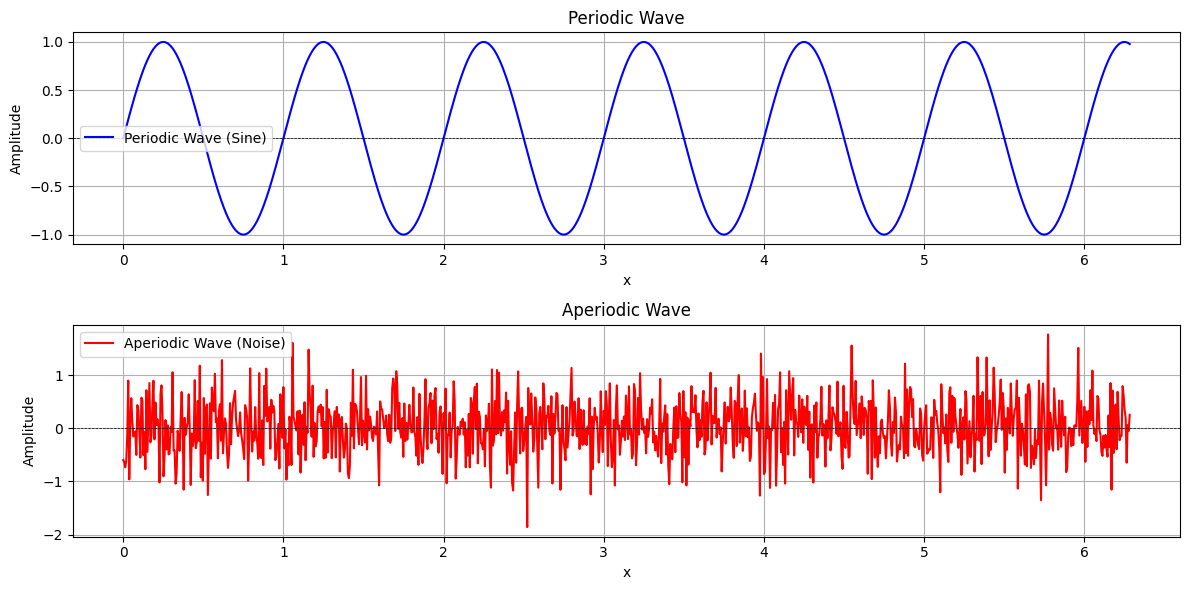

In [1]:
# To make the rest of the code work, we need to load some Python libraries: 
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import welch

# Define x
x = np.linspace(0, 2 * np.pi, 1000)

# Generate a periodic wave (sine wave)
periodic_wave = np.sin(2 * np.pi * x)

# Generate an aperiodic wave (random noise)
aperiodic_wave = np.random.normal(0, 0.5, len(x))

# Plot the periodic and aperiodic waves
plt.figure(figsize=(12, 6))

# Plot periodic wave
plt.subplot(2, 1, 1)
plt.plot(x, periodic_wave, label='Periodic Wave (Sine)', color='blue')
plt.title('Periodic Wave')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()

# Plot aperiodic wave
plt.subplot(2, 1, 2)
plt.plot(x, aperiodic_wave, label='Aperiodic Wave (Noise)', color='red')
plt.title('Aperiodic Wave')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Longitudinal and transverse waves

Mechanical waves travel through a medium (air, water, or a solid) by making particles vibrate. They are classified by the direction of particle motion relative to the direction the wave travels:

- **Longitudinal waves**: Particles oscillate parallel to the direction the wave travels. Sound waves in air are a common example.
- **Transverse waves**: Particles oscillate perpendicular to the direction of travel. Examples include waves on a string or surface water waves.

The distinction matters because it governs how energy moves through different materials.

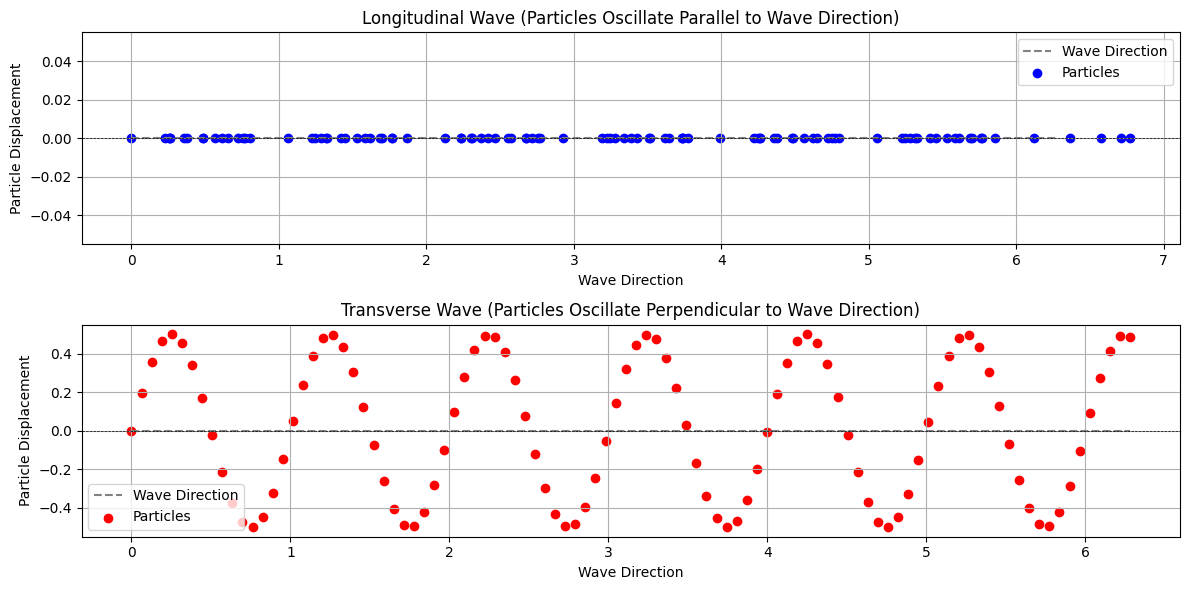

In [2]:
# Define parameters for the waves
x = np.linspace(0, 2 * np.pi, 100)
amplitude = 0.5
frequency = 1

# Generate waveforms
wave = np.sin(2 * np.pi * frequency * x)

# Create particle positions for longitudinal and transverse waves
longitudinal_x = x + amplitude * np.sin(2 * np.pi * frequency * x)
longitudinal_y = np.zeros_like(x)  # No vertical displacement

transverse_x = x  # No horizontal displacement
transverse_y = amplitude * np.sin(2 * np.pi * frequency * x)

# Create the figure
plt.figure(figsize=(12, 6))

# Plot longitudinal wave
plt.subplot(2, 1, 1)
plt.plot(x, np.zeros_like(x), '--', color='gray', label='Wave Direction')
plt.scatter(longitudinal_x, longitudinal_y, color='blue', label='Particles')
plt.title('Longitudinal Wave (Particles Oscillate Parallel to Wave Direction)')
plt.xlabel('Wave Direction')
plt.ylabel('Particle Displacement')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()

# Plot transverse wave
plt.subplot(2, 1, 2)
plt.plot(x, np.zeros_like(x), '--', color='gray', label='Wave Direction')
plt.scatter(transverse_x, transverse_y, color='red', label='Particles')
plt.title('Transverse Wave (Particles Oscillate Perpendicular to Wave Direction)')
plt.xlabel('Wave Direction')
plt.ylabel('Particle Displacement')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Frequency

Frequency is the number of complete oscillations, or cycles, a sound wave completes per second, measured in Hertz (Hz). It sets the audible *pitch* of a sound: higher frequencies sound higher, lower frequencies sound lower. It is one of the properties we lean on most when we analyse and describe sound.

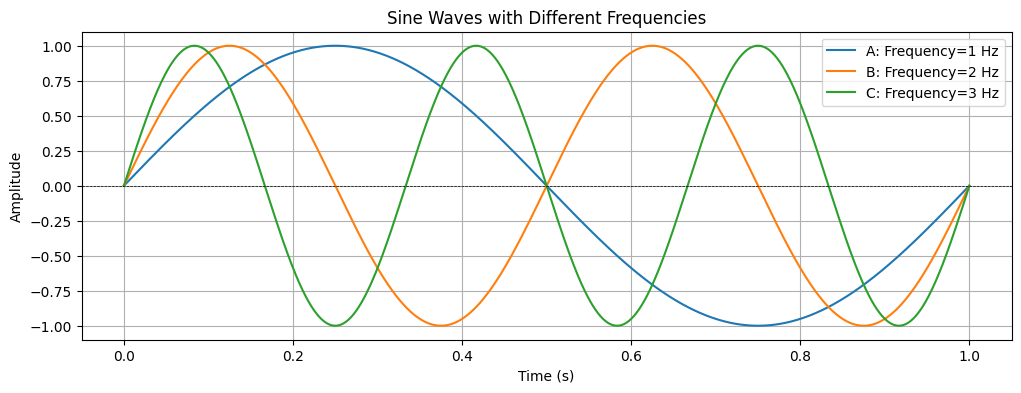

In [3]:
# Define parameters for the sine waves
time = np.linspace(0, 1, 1000)  # Time in seconds (0 to 1 second)
freq1, freq2, freq3 = 1, 2, 3  # Frequencies of the sine waves in Hz
wave1 = np.sin(2 * np.pi * freq1 * time)  # First sine wave
wave2 = np.sin(2 * np.pi * freq2 * time)  # Second sine wave
wave3 = np.sin(2 * np.pi * freq3 * time)  # Third sine wave

# Plot the sine waves
plt.figure(figsize=(12, 4))
plt.plot(time, wave1, label=f'A: Frequency={freq1} Hz')
plt.plot(time, wave2, label=f'B: Frequency={freq2} Hz')
plt.plot(time, wave3, label=f'C: Frequency={freq3} Hz')
plt.title('Sine Waves with Different Frequencies')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

The frequency of a wave is closely related to its *period*, the time it takes for one complete cycle to occur. The period is measured in seconds (s), while frequency counts the cycles that occur per second, measured in Hertz (Hz).

The frequency of a wave ($f$) is the reciprocal of its period ($T$), and vice versa:

$$f = \frac{1}{T} \qquad T = \frac{1}{f}$$

For example, if a wave has a period of 0.01 seconds, its frequency is f = 1 / 0.01 = 100 Hz. If the frequency is 50 Hz, the period is T = 1 / 50 = 0.02 seconds.

### Amplitude

A sound wave's amplitude is what we hear as how "loud" it is. More precisely, amplitude is the maximum displacement of particles in the medium from their rest position as the wave passes. On a graph such as a sine wave, it is the peak value above and below the centre line (zero).

Higher amplitude means more energy in the wave and a louder sound; lower amplitude means a quieter one. Amplitude is typically measured in metres (for displacement), pascals (for pressure), or volts (for electrical signals).

In the plot below, each sine wave has a different amplitude. The peaks and troughs mark the maximum and minimum values, showing how amplitude relates to loudness.

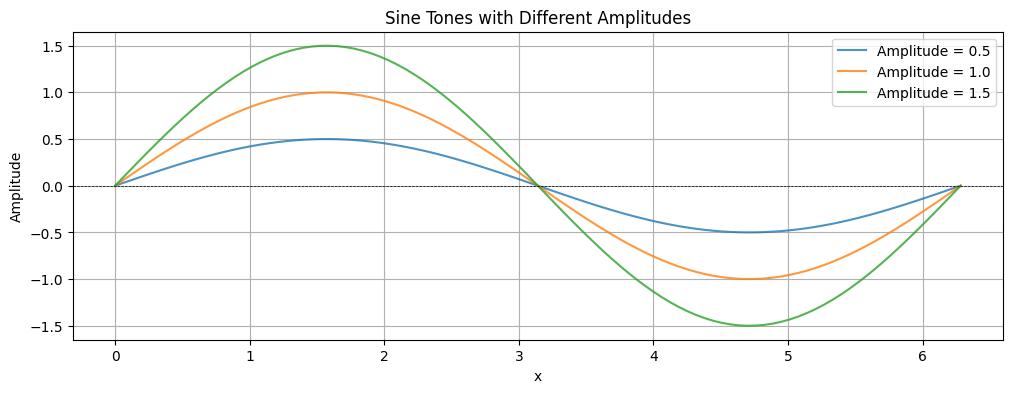

In [4]:
# Define amplitudes for the sine tones
amplitude1 = 0.5
amplitude2 = 1.0
amplitude3 = 1.5

# Generate the sine tones
sine1 = amplitude1 * np.sin(x)
sine2 = amplitude2 * np.sin(x)
sine3 = amplitude3 * np.sin(x)

# Plot the sine tones
plt.figure(figsize=(12, 4))
plt.plot(x, sine1, label='Amplitude = 0.5', alpha=0.8)
plt.plot(x, sine2, label='Amplitude = 1.0', alpha=0.8)
plt.plot(x, sine3, label='Amplitude = 1.5', alpha=0.8)
plt.title('Sine Tones with Different Amplitudes')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

### Sound pressure level (SPL)

[Sound pressure level](https://en.wikipedia.org/wiki/Sound_pressure#Sound_pressure_level) (SPL) measures the pressure variation caused by a sound wave. It is used across acoustics, audio engineering, and environmental noise monitoring to gauge sound levels and check compliance with safety standards. SPL tells us how sound behaves in different environments and how it affects human hearing.

SPL is expressed in [decibels](https://en.wikipedia.org/wiki/Decibel) (dB), a *[logarithmic](https://en.wikipedia.org/wiki/Logarithmic_scale)* unit for the ratio of two values. On a logarithmic scale, each step is a multiplication rather than an addition. An increase of 10 dB corresponds to a tenfold increase in sound intensity, and 20 dB to a hundredfold increase. This lets us represent the enormous range of sound pressures compactly, which suits us well, since human hearing also responds to loudness logarithmically rather than linearly.

The formula for SPL in decibels is:

$$\text{SPL} = 20 \log_{10}\left(\frac{p}{p_0}\right)$$

where $p$ is the measured sound pressure and $p_0$ is the reference sound pressure (typically 20 μPa in air).

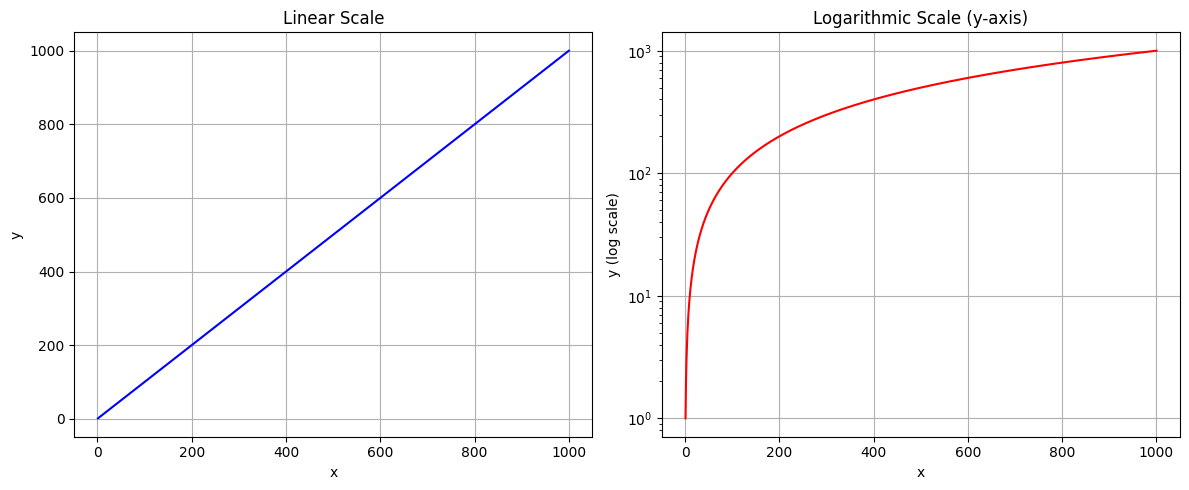

In [5]:
# Plot illustrating regular (linear) vs logarithmic scale

x = np.linspace(1, 1000, 1000)
y = x  # Linear relationship

plt.figure(figsize=(12, 5))

# Linear scale plot
plt.subplot(1, 2, 1)
plt.plot(x, y, color='blue')
plt.title('Linear Scale')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()

# Logarithmic scale plot
plt.subplot(1, 2, 2)
plt.plot(x, y, color='red')
plt.yscale('log')
plt.title('Logarithmic Scale (y-axis)')
plt.xlabel('x')
plt.ylabel('y (log scale)')
plt.grid()

plt.tight_layout()
plt.show()

A 10 dB increase in SPL is generally heard as about twice as loud. This follows from the logarithmic response of hearing. A 10 dB rise means the sound pressure increases by a factor of about 3.16, yet our sense of loudness roughly doubles.

The *3 dB rule* says that adding a second identical sound source raises the SPL by about 3 dB, which is double the energy but only a slight gain in perceived loudness. If a single speaker produces 70 dB SPL at a given point, a second identical speaker playing the same signal at the same place brings it to roughly 73 dB. The sound pressure doubles, giving the 3 dB increase, but the loudness we hear is only a little greater, not doubled. In the same way, two 60 dB sources combine to about 63 dB.

You also need the *inverse-square law*: when the distance from a sound source doubles, the sound pressure drops to one-quarter, a 6 dB reduction in SPL. This is why sounds fall away so quickly as you move away from the source.

```{image} figures/external/acoustics/04-Inverse_square_law_mk.svg
:alt: Inverse Square Law
:width: 100%
```

*Figure: Illustration of the Inverse-Square Law, showing how sound pressure decreases with distance ([Wikipedia](https://commons.wikimedia.org/wiki/File:Inverse_square_law_mk.svg)).*

### Phase

Phase describes the position of a point within a wave cycle, measured in degrees or radians. Differences in phase between waves can lead to constructive or destructive interference.

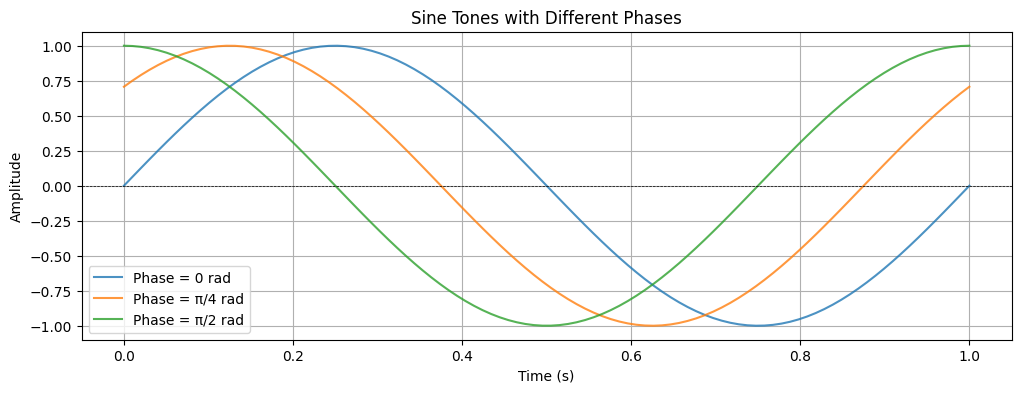

In [6]:
# Define the amplitude and frequency for the sine tones
x = np.linspace(0, 2 * np.pi, 100)
amplitude = 1
frequency = 1  # Frequency in Hz

# Define the phases for the three sine tones
phase1 = 0  # 0 radians
phase2 = np.pi / 4  # 45 degrees in radians
phase3 = np.pi / 2  # 90 degrees in radians

# Convert x to time in seconds
time_in_seconds = x / (2 * np.pi * frequency)

# Generate the sine tones
sine1 = amplitude * np.sin(2 * np.pi * frequency * time_in_seconds + phase1)
sine2 = amplitude * np.sin(2 * np.pi * frequency * time_in_seconds + phase2)
sine3 = amplitude * np.sin(2 * np.pi * frequency * time_in_seconds + phase3)

# Plot the sine tones
plt.figure(figsize=(12, 4))
plt.plot(time_in_seconds, sine1, label='Phase = 0 rad', alpha=0.8)
plt.plot(time_in_seconds, sine2, label='Phase = π/4 rad', alpha=0.8)
plt.plot(time_in_seconds, sine3, label='Phase = π/2 rad', alpha=0.8)
plt.title('Sine Tones with Different Phases')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

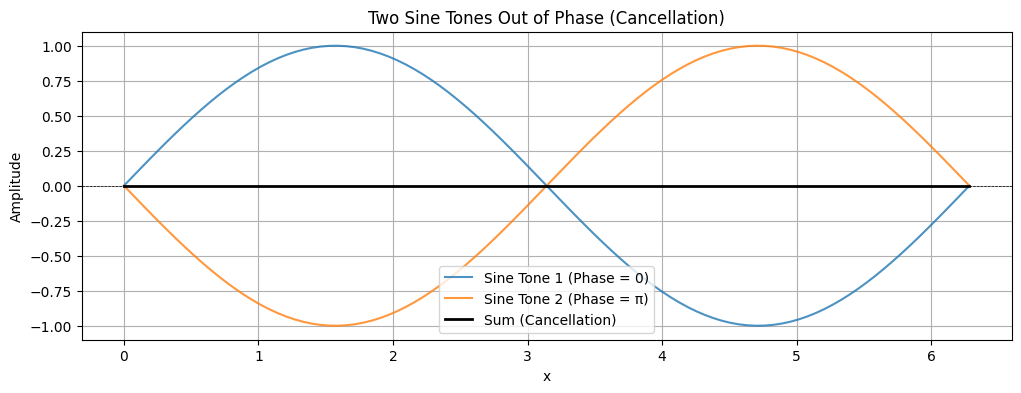

In [7]:
# Define amplitude and frequency for the sine tones
amplitude = 1
frequency = 1  # Frequency in Hz

# Use x from previous cells
# Define two sine tones with opposite phases (0 and pi)
sine1 = amplitude * np.sin(x)
sine2 = amplitude * np.sin(x + np.pi)  # 180 degrees out of phase

# Sum of the two sine tones
sum_wave = sine1 + sine2

# Plot the two sine tones and their sum
plt.figure(figsize=(12, 4))
plt.plot(x, sine1, label='Sine Tone 1 (Phase = 0)', alpha=0.8)
plt.plot(x, sine2, label='Sine Tone 2 (Phase = π)', alpha=0.8)
plt.plot(x, sum_wave, label='Sum (Cancellation)', color='black', linewidth=2)
plt.title('Two Sine Tones Out of Phase (Cancellation)')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

```{exercise}
:label: Phase in production

Have you tried swapping the phase in a music track? Try [this phase cancellation](https://l2ork.music.vt.edu:3000/?url=VTWaves/Phase-Cancellation-Emscripten.pd) web experiment. 
```

### Beating waves

When two sound waves of slightly different frequencies are played together, they interfere with each other. This interference causes the amplitude of the combined wave to fluctuate up and down in a regular pattern, called a *beat*. The *[beat frequency](https://en.wikipedia.org/wiki/Beat_(acoustics))* is equal to the difference between the two original frequencies. For example, two tones with frequencies 440 Hz and 441 Hz will cause a beat frequency of 1 Hz. You hear this as the sound getting louder and softer at this beat frequency.

Mathematically, if you add two sine waves with close frequencies, the result is a wave whose amplitude varies slowly, creating the "beating" effect. This is commonly heard when tuning musical instruments or when two notes are almost, but not quite, in tune.

The demo below shows the effect twice over. The plot uses frequencies slow enough that you can see the individual cycles and watch them drift in and out of step. The audio player under it uses audible frequencies, where the cycles are far too fast to draw but the slow rise and fall of loudness is exactly what you hear when tuning.

In [ ]:
# Define parameters for the two sine waves
frequency1 = 5  # Frequency of the first wave in Hz
frequency2 = 5.5  # Frequency of the second wave in Hz
amplitude = 1  # Amplitude of the waves
time = np.linspace(0, 5, 1000)  # Time array from 0 to 5 seconds

# Generate the two sine waves
wave1 = amplitude * np.sin(2 * np.pi * frequency1 * time)
wave2 = amplitude * np.sin(2 * np.pi * frequency2 * time)

# Generate the resulting wave (superposition)
beating_wave = wave1 + wave2

# Plot the individual waves and the resulting wave
plt.figure(figsize=(12, 4))
plt.plot(time, wave1, label='Wave 1', alpha=0.7)
plt.plot(time, wave2, label='Wave 2', alpha=0.7)
plt.plot(time, beating_wave, label='Beating Wave', color='black', linewidth=2)
plt.title('Beating Waves: Interference of Two Sine Waves')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

# The same interference at audible frequencies. 440 Hz against 443 Hz beats
# three times a second; its individual cycles are far too fast to plot, which
# is why the figure above uses 5 Hz instead.
from IPython.display import Audio, display

sr = 22050
duration = 3.0
t_audio = np.linspace(0, duration, int(sr * duration), endpoint=False)
f1, f2 = 440.0, 443.0
tone = 0.5 * (np.sin(2 * np.pi * f1 * t_audio) + np.sin(2 * np.pi * f2 * t_audio))
display(Audio(tone, rate=sr))


```{exercise}
:label: Sine tones

Try out making sine tones in [Glicol](https://glicol.org/tour#basicconnection). Change the amplitude and frequency to hear how they are affecting what you hear. Try adding an extra sine tone with a different frequency to create a beat frequency.

Then test the relationship directly in this [interactive beat app](https://fourms.github.io/sensingsoundandmusic/beating-demo.html). Set two frequencies a few hertz apart, count the beats per second, and check that the count matches the difference between the two frequencies.
```

### Complex waves

A *complex wave* is a sound wave that consists of multiple frequencies combined together, rather than a single pure tone. Most sounds we hear in everyday life, such as musical notes, speech, or environmental noises, are complex waves.

### Demo: building a tone from harmonics

A complex periodic tone can be built by adding sine waves at integer multiples of a fundamental frequency. Adding the first 20 harmonics with amplitudes proportional to 1/n approximates a sawtooth wave, and the more harmonics, the sharper the corner.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

sr = 22050
dur = 2.0
t = np.linspace(0, dur, int(sr * dur), endpoint=False)
f0 = 220.0

saw = np.zeros_like(t)
for n in range(1, 21):
    saw += (1.0 / n) * np.sin(2 * np.pi * f0 * n * t)
saw *= 0.2

display(Audio(saw, rate=sr))

fig, ax = plt.subplots(1, 2, figsize=(10, 2.8))
seg = int(sr * 0.02)
ax[0].plot(t[:seg], saw[:seg], lw=0.8)
ax[0].set_title("Sum of 20 harmonics (approx. sawtooth)")
ax[0].set_xlabel("Time (s)")
ax[1].stem(range(1, 21), [1.0 / n for n in range(1, 21)])
ax[1].set_title("Harmonic amplitudes (1/n)")
ax[1].set_xlabel("Harmonic number")
plt.tight_layout()
plt.show()


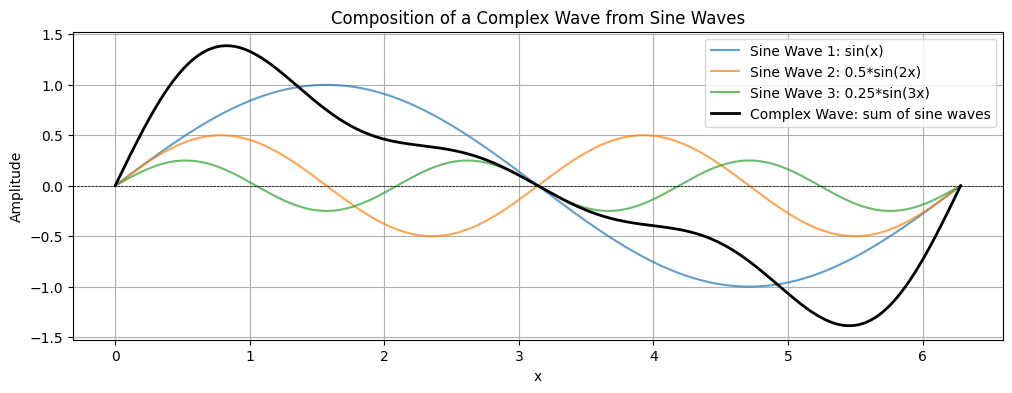

In [9]:
# Define parameters for the sine waves
x = np.linspace(0, 2 * np.pi, 1000)
wave1 = np.sin(x)  # First sine wave
wave2 = 0.5 * np.sin(2 * x)  # Second sine wave with half amplitude and double frequency
wave3 = 0.25 * np.sin(3 * x)  # Third sine wave with quarter amplitude and triple frequency

# Sum of the sine waves (complex wave)
complex_wave = wave1 + wave2 + wave3

# Plot the individual sine waves and the complex wave
plt.figure(figsize=(12, 4))
plt.plot(x, wave1, label='Sine Wave 1: sin(x)', alpha=0.7)
plt.plot(x, wave2, label='Sine Wave 2: 0.5*sin(2x)', alpha=0.7)
plt.plot(x, wave3, label='Sine Wave 3: 0.25*sin(3x)', alpha=0.7)
plt.plot(x, complex_wave, label='Complex Wave: sum of sine waves', color='black', linewidth=2)
plt.title('Composition of a Complex Wave from Sine Waves')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

### Time vs frequency domain

Sound can be shown visually in two very different ways:

- **Time domain**: A *waveform display* shows how a signal's amplitude changes over time. This view brings out the shape, duration, and dynamics of the signal.

- **Frequency domain**: A *spectrum* plot or *spectrogram* shows how much of the signal sits in each frequency band. This view is the one to reach for when working with pitch, timbre, and spectral content.

### The Fourier transform

The [Fourier transform](https://en.wikipedia.org/wiki/Fourier_transform) is a mathematical operation that converts a time-domain signal into its frequency-domain representation. Any complex wave can be broken down into a sum of simpler sinusoids with different frequencies, amplitudes, and phases, a process called *Fourier analysis*. The technique was developed by the French mathematician [Joseph Fourier](https://en.wikipedia.org/wiki/Joseph_Fourier) (1768–1830) and underpins modern signal processing and harmonic analysis.

In practice, the fast Fourier transform (FFT) is an efficient algorithm for computing the Fourier transform, fast enough for real-time analysis of audio in music technology, acoustics, and audio engineering.

### Spectrum and spectrogram

The Fourier transform lets us picture sound in the frequency domain in two main ways:

- **Spectrum**: A plot with frequency on the x-axis and magnitude on the y-axis. It gives a snapshot of the frequency content averaged over the whole signal, that is, which frequencies are present and how strong each one is.

- **Spectrogram**: A representation with time on the x-axis, frequency on the y-axis, and intensity (energy) shown by colour or brightness. It reveals how the frequency content changes over time, so you can see the temporal structure of a sound. Brighter or more intense colours mean stronger energy at a given frequency and time. This makes spectrograms a good fit for musical phrases, speech patterns, and transient events.

To see how the two relate, you can plot the spectrum rotated 90 degrees so its frequency axis lines up with the spectrogram's. The contrast is then clear, since the spectrum summarises the whole signal while the spectrogram shows how it develops over time.

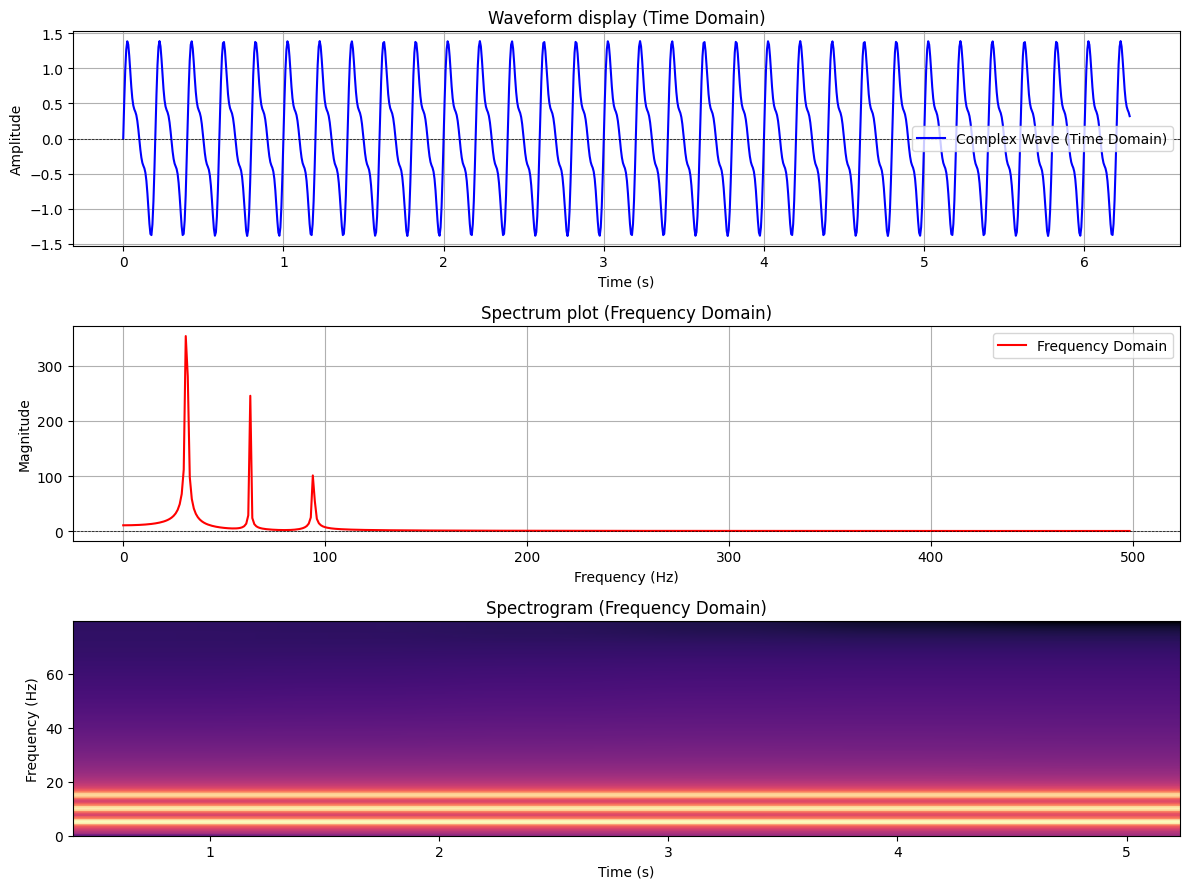

In [10]:
# Define parameters for the complex wave
frequency1 = 5  # Frequency of the first wave in Hz
frequency2 = 10  # Frequency of the second wave in Hz
frequency3 = 15  # Frequency of the third wave in Hz
amplitude1 = 1
amplitude2 = 0.5
amplitude3 = 0.25

# Generate the complex wave as a sum of three sine waves
wave1 = amplitude1 * np.sin(2 * np.pi * frequency1 * x)
wave2 = amplitude2 * np.sin(2 * np.pi * frequency2 * x)
wave3 = amplitude3 * np.sin(2 * np.pi * frequency3 * x)
complex_wave = wave1 + wave2 + wave3

# Compute the Fourier Transform of the complex wave
N = len(complex_wave)
T = (x[1] - x[0]) / (2 * np.pi)
frequencies = fftfreq(N, T)[:N // 2]
fft_values = fft(complex_wave)[:N // 2]

# Plot time domain, frequency domain, and spectrogram
plt.figure(figsize=(12, 9))

# Time domain plot
plt.subplot(3, 1, 1)
plt.plot(x, complex_wave, label='Complex Wave (Time Domain)', color='blue')
plt.title('Waveform display (Time Domain)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()

# Frequency domain plot
plt.subplot(3, 1, 2)
plt.plot(frequencies, np.abs(fft_values), label='Frequency Domain', color='red')
plt.title('Spectrum plot (Frequency Domain)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()

# Spectrogram plot
plt.subplot(3, 1, 3)
plt.specgram(complex_wave, NFFT=256, Fs=1/(x[1]-x[0]), noverlap=128, cmap='magma')
plt.title('Spectrogram (Frequency Domain)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

When generating a spectrogram, the audio signal is divided into short time windows, each processed with the Fourier transform. The choice of *window size* and *overlap* sets the trade-off between time and frequency resolution:

- **Short window (e.g., 256–512 samples):** Better *time resolution*, so rapid changes like transients, attacks, or percussive sounds are easier to see. Frequency resolution suffers, so pitch detail is less precise.
- **Long window (e.g., 2048–4096 samples):** Better *frequency resolution*, revealing fine pitch detail and harmonics. Time resolution suffers, so fast events blur.
- **Overlap:** Overlapping consecutive windows (typically 50%–75%) smooths the transitions between segments and adds temporal detail without needing more samples. A common choice is 50% overlap (e.g., with a 1024-sample window, the next window starts 512 samples later).

The best window size and overlap depend on the sound. Speech or transient-rich signals tend to call for shorter windows with moderate overlap, while sustained musical tones or harmonic analysis benefit from longer windows with higher overlap.

It is also worth considering whether one uses *linear* or *logarithmic* scales in the spectrum or spectrogram. On a linear frequency axis, the frequencies are evenly spaced (e.g., 100 Hz, 200 Hz, 300 Hz). This is handy for technical work, but it compresses the low frequencies and stretches out the high ones, hiding bass and mid-range detail. A logarithmic scale spaces frequencies proportionally instead (octaves: 100 Hz, 200 Hz, 400 Hz, 800 Hz). This matches human hearing and musical pitch perception, so the structure across the whole spectrum is easier to read.

The intensity (colour) scale in a spectrogram can likewise be linear or logarithmic. A logarithmic scale compresses the dynamic range so that both loud and quiet sounds stay visible, which is the standard for audio spectrograms.

### Window types

When computing a spectrogram, the audio signal is divided into short overlapping segments, and each segment is multiplied by a mathematical function called a [window](https://en.wikipedia.org/wiki/Window_function) before the Fourier transform is applied. The window reduces edge effects and spectral leakage, which improves the accuracy of the frequency analysis.

The choice of window sets a trade-off between frequency resolution and leakage. In music and audio analysis the *Hann* window is the usual default, because it performs well across the board; you will meet it as the standard setting in Sonic Visualiser, Audacity, and librosa.

:::{note} Dig deeper: window types
:class: dropdown
- **Hanning (Hann) window:** Tapers the segment smoothly to zero at the edges, reducing spectral leakage. Widely used for audio analysis.
- **Hamming window:** Similar to Hann but with slightly different tapering, giving a good balance between main-lobe width and side-lobe suppression.
- **Blackman window:** Offers even better side-lobe suppression, useful when minimising leakage is critical.
- **Rectangular window:** No tapering (all ones); it can cause heavy spectral leakage and is rarely used in practice.
- **Terhardt window:** Designed by Ernst Terhardt, tailored for psychoacoustic analysis and auditory modelling. It emphasises perceptual aspects of spectral analysis, aiming to reflect how the ear perceives sound, though it is less common in general audio processing.
:::

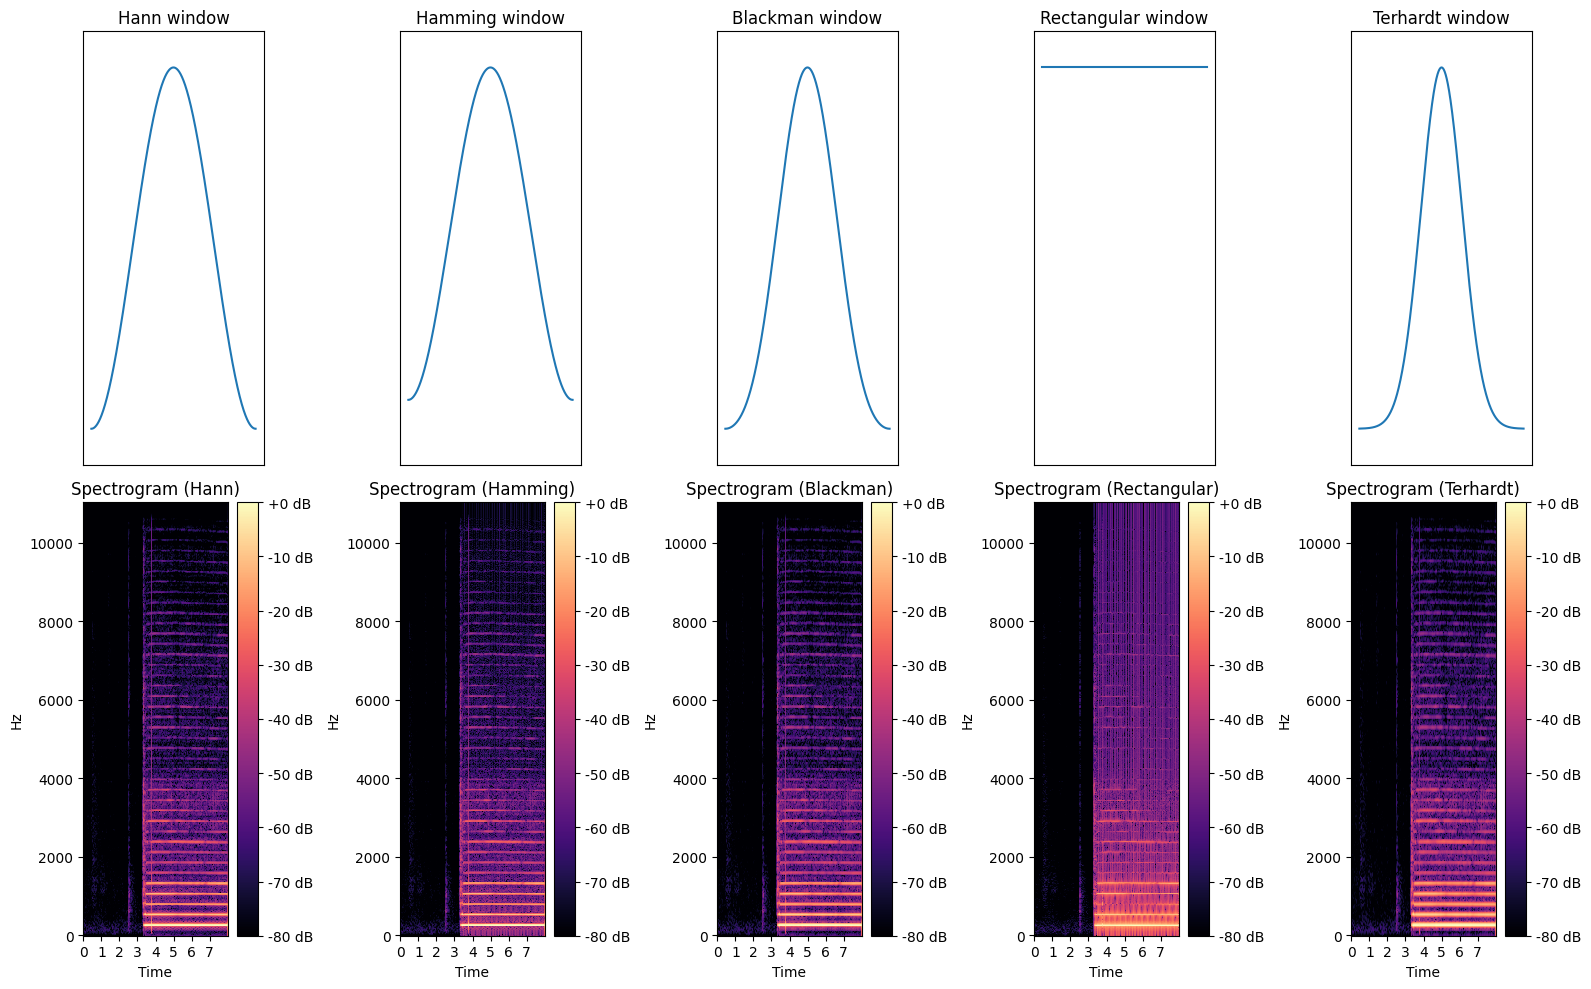

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Use a short local audio example for the window comparison
y, sr = librosa.load('audio/SoundAction122-Saxophone_tone.wav', sr=22050, mono=True, duration=4.0)
window_types = ['hann', 'hamming', 'blackman', 'rectangular', 'terhardt']

# Define Terhardt window function
def terhardt_window(N):
    """
    Create a Terhardt window for psychoacoustic analysis.
    This is a simplified version - adjust based on your needs.
    """
    n = np.arange(N)
    # Simple approximation of Terhardt window
    w = np.exp(-0.5 * ((n - N/2) / (N/8))**2)
    return w / np.max(w)


win_length = 1024

plt.figure(figsize=(16, 10))
for i, win in enumerate(window_types):
    # Get window array
    if win == 'terhardt':
        w = terhardt_window(win_length)
    else:
        w = np.hanning(win_length) if win == 'hann' else \
            np.hamming(win_length) if win == 'hamming' else \
            np.blackman(win_length) if win == 'blackman' else \
            np.ones(win_length)  # boxcar

    # Plot window
    plt.subplot(2, len(window_types), i + 1)
    plt.plot(w)
    plt.title(f"{win.capitalize()} window")
    plt.ylim(-0.1, 1.1)
    plt.xticks([])
    plt.yticks([])

    # Compute STFT with the given window
    D = librosa.stft(y, window=w, n_fft=win_length, hop_length=256)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    # Plot spectrogram
    plt.subplot(2, len(window_types), i + 1 + len(window_types))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
    plt.title(f"Spectrogram ({win.capitalize()})")
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()

plt.show()

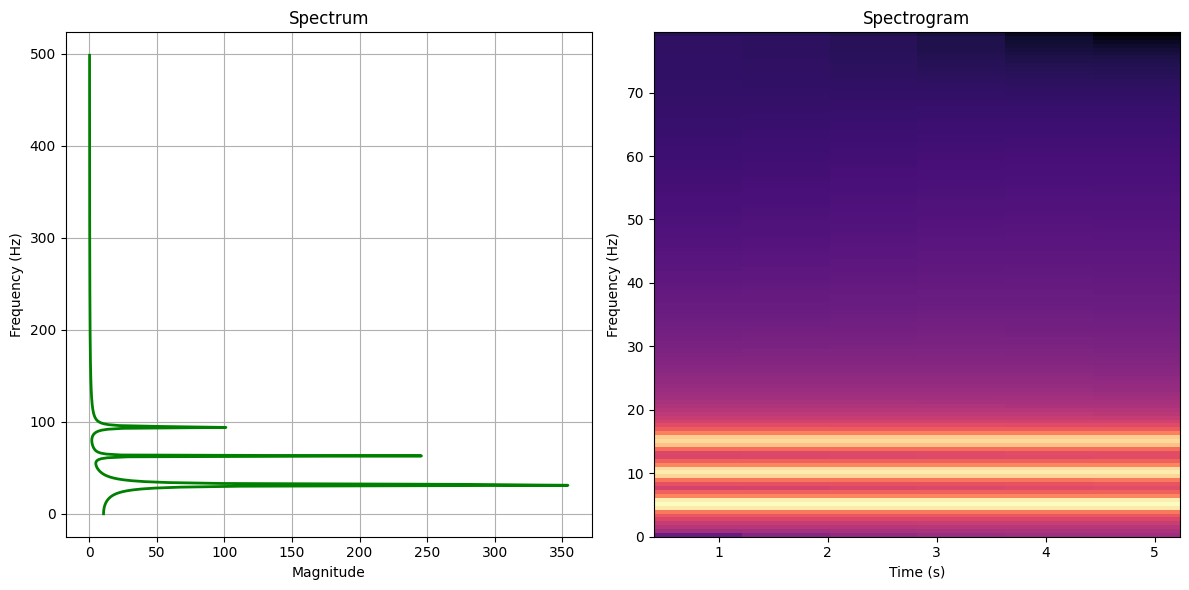

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: Spectrum turned 90 degrees
axes[0].plot(np.abs(fft_values), frequencies, color='green', linewidth=2)
axes[0].set_title('Spectrum')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_xlabel('Magnitude')
axes[0].grid()

# Right: Spectrogram
axes[1].specgram(complex_wave, NFFT=256, Fs=1/(x[1]-x[0]), noverlap=128, cmap='magma')
axes[1].set_title('Spectrogram')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

```{note}
You may come across the term *sonogram* in the literature. It is essentially a spectrogram of sound signals. For sound and music, they are used interchangeably. However, spectrograms are more general, and can be used to decompose also other types of complex time-based signals.
```


### Noise

Noise is random or unpredictable fluctuation in sound, usually without a clear pitch or musical quality. In acoustics and audio engineering, the different types of noise are distinguished by their frequency content and how energy is spread across the spectrum. Common types include:

- **White noise**: Contains all frequencies at equal intensity, giving a "hissing" sound like static from a radio or TV. It is often used for sound masking and audio testing thanks to its even frequency distribution.
- **Pink noise**: Has equal energy per octave, so its power decreases as frequency rises. This gives it a deeper sound, like rainfall or wind, and makes it useful for audio calibration and sleep aids.
- **Brownian noise (red noise)**: Emphasises even lower frequencies than pink noise, producing a deep rumble or distant thunder. It is generated by random walk processes and is sometimes called "red noise."
- **Blue noise**: Carries more energy at higher frequencies, giving a brighter, sharper sound. Rare in nature, it is used in dithering for digital audio and image processing.
- **Grey noise**: Shaped so that all frequencies are perceived as equally loud, based on psychoacoustic principles. It is used in research and testing to account for the sensitivity of human hearing.

These noise types are "constant" in the sense that their characteristics stay the same. There is also *impulse noise*: sudden, short bursts such as clicks, pops, or bangs. Impulse noise is common around machinery, gunshots, and electrical discharges.

Such noise types turn up in audio testing, sound masking, electronic music, and many scientific applications. Knowing the character of each one helps when designing systems for noise reduction, audio analysis, and environmental sound studies.

The differences show up most clearly in the *spectrum*, that is, the average energy at each frequency. In the figure below, the curves are aligned at 1 kHz so that their shapes can be compared directly. The slope is what gives each noise its colour: white noise is flat, pink noise falls by 3 dB per octave, brownian noise by 6 dB per octave, and blue noise rises by 3 dB per octave. Grey noise follows the inverse of a hearing sensitivity curve, boosting the regions where the ear is least sensitive. Impulse noise, on the other hand, has a flat spectrum much like white noise; what sets it apart is how its energy is distributed in *time*, not in frequency.

In [ ]:
# Define parameters
sampling_rate = 44100  # Hz
duration = 4  # seconds
N = sampling_rate * duration
rng = np.random.default_rng(1)

# Coloured noise is easiest to generate in the frequency domain: start from
# white noise and scale each frequency bin by f**(-beta/2), where beta sets
# how steeply the power falls off with frequency.
def coloured_noise(N, beta, rng):
    spectrum = np.fft.rfft(rng.normal(0, 1, N))
    freqs = np.fft.rfftfreq(N, 1 / sampling_rate)
    scaling = np.ones_like(freqs)
    scaling[1:] = freqs[1:] ** (-beta / 2)
    scaling[0] = 0  # remove the DC component
    return np.fft.irfft(spectrum * scaling, n=N)

white_noise = coloured_noise(N, 0, rng)      # flat spectrum
pink_noise = coloured_noise(N, 1, rng)       # -3 dB per octave
brownian_noise = coloured_noise(N, 2, rng)   # -6 dB per octave
blue_noise = coloured_noise(N, -1, rng)      # +3 dB per octave

# Grey noise is white noise shaped by the inverse of a hearing sensitivity
# curve, here approximated by inverting the standard A-weighting filter
# (with the boost limited so the curve stays readable).
def a_weighting(f):
    f = np.maximum(f, 1e-6)
    num = 12194**2 * f**4
    den = ((f**2 + 20.6**2)
           * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2))
           * (f**2 + 12194**2))
    return num / den

freqs_full = np.fft.rfftfreq(N, 1 / sampling_rate)
grey_gain = a_weighting(1000) / a_weighting(freqs_full)
grey_gain = np.clip(grey_gain, 10**(-15 / 20), 10**(15 / 20))
grey_spectrum = np.fft.rfft(rng.normal(0, 1, N)) * grey_gain
grey_spectrum[0] = 0
grey_noise = np.fft.irfft(grey_spectrum, n=N)

# Impulse noise: random sparse spikes
impulse_noise = np.zeros(N)
impulse_indices = rng.choice(N, size=int(N * 0.001), replace=False)
impulse_noise[impulse_indices] = rng.choice([-1.0, 1.0], size=len(impulse_indices))

noises = [
    ("White", white_noise, "black", "-"),
    ("Pink", pink_noise, "deeppink", "-"),
    ("Brownian", brownian_noise, "saddlebrown", "-"),
    ("Blue", blue_noise, "royalblue", "-"),
    ("Grey", grey_noise, "grey", "--"),
    ("Impulse", impulse_noise, "seagreen", ":"),
]

# Plot the average spectrum of each noise type in the same panel
plt.figure(figsize=(12, 6))
for name, noise, colour, style in noises:
    f, psd = welch(noise, fs=sampling_rate, nperseg=4096)
    psd_db = 10 * np.log10(psd + 1e-20)
    # Align all curves at 1 kHz so the shapes can be compared directly
    ref = np.interp(1000, f, psd_db)
    plt.semilogx(f[1:], psd_db[1:] - ref, label=f'{name} noise',
                 color=colour, linestyle=style)

plt.title('Average spectra of different noise types (aligned at 1 kHz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Relative power (dB)')
plt.xlim(20, sampling_rate / 2)
plt.ylim(-45, 45)
plt.grid(which='both', alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

```{exercise}
:label: Make spectrograms in Sonic Visualiser

Download and install [Sonic Visualiser](https://www.sonicvisualiser.org/), a free tool for visualising and analysing audio files. Open a sound file (such as a recording or sample) and experiment with creating spectrograms:

- Load your audio file into Sonic Visualiser.
- Add a new spectrogram layer (choose "Layer" → "Add Spectrogram").
- Adjust the spectrogram settings (window size, colour map, etc.) to explore how they affect the visualisation.
- Try zooming in and out to examine different time and frequency regions.

How does the spectrogram help you understand the frequency content and changes over time in your audio? Compare the visual patterns for different sounds (speech, music, noise).
```

## Sound propagation

Sound propagation refers to how sound waves travel through different environments and interact with materials. 

### Medium of propagation

Sound needs a medium, such as air, water, or solids, to travel. The particles in these media vibrate and transmit energy from one place to another. The speed and efficiency of sound propagation depend on the medium’s properties, especially density and elasticity. Generally, sound travels faster in materials that are more elastic and have closely packed particles.

Here are some examples of the [speed of sound](https://en.wikipedia.org/wiki/Speed_of_sound) in different media:

| Medium   | Speed (m/s) |
|----------|-------------|
| Air      | 343         |
| Helium   | 965         |
| Water    | 1481        |
| Glass    | 4540        |
| Iron     | 5120        |
| Diamond  | 12000       |

Sound moves fastest in solids (like iron or diamond) because their particles are tightly packed and transmit vibrations efficiently. For example, you can hear a distant train by placing your ear on the rail, as sound travels much faster through metal than air.

Temperature, humidity, and altitude also affect the speed of sound. Warmer air or higher humidity generally increases the speed, while higher altitude (lower air density) decreases it.

### Reflection, refraction, diffraction, and absorption

Four physics concepts are central to how sound behaves in general, and in rooms and instruments in particular:

- **Reflection**: Sound waves bounce off surfaces, creating echoes and shaping acoustics. In a concert hall, hard walls and ceilings reflect sound, producing reverberation and echoes. Inside a guitar, sound waves reflect off the wooden body, reinforcing certain frequencies and contributing to the instrument's tone.

- **Refraction**: When sound moves between media (e.g., air to water), its speed changes and the wave bends. Temperature gradients in a room can bend sound waves, affecting how sound travels from the stage to the audience. In wind instruments, sound waves refract as they pass through air of varying temperature or humidity inside the instrument, subtly changing pitch and timbre.

- **Diffraction**: Sound waves bend around obstacles and spread out after passing through openings. Sound diffracts around furniture or pillars, so you can hear someone speaking even when they are out of direct line of sight. The sound from a violin's f-holes diffracts, helping project the instrument in all directions.

- **Absorption**: Materials soak up sound energy, reducing its intensity. Carpets, curtains, and acoustic panels absorb sound, cutting echoes and making rooms quieter. The type of wood or material in a drum absorbs some sound energy, affecting the instrument's resonance and sustain.

Together these principles shape how we experience sound everywhere from open fields to concert halls, and they influence both the design and the performance of musical instruments.

```{image} figures/reflection-refraction-copilot.jpg
:alt: reflection-refraction-copilot.jpg
:width: 100%
```

## Room acoustics

Room acoustics looks at how the physical characteristics of a space shape sound quality. A room's shape, size, and materials all affect how sound waves behave, and with them the clarity, warmth, and reverberation we hear.

### Room size and shape

A room's dimensions and geometry decide how sound waves reflect, interact, and form standing waves. Irregular shapes and non-parallel surfaces help reduce unwanted echoes and resonances, while rectangular rooms with parallel walls are prone to standing waves, where certain frequencies are reinforced by repeated reflections.

*Standing waves* form when sound waves reflect between parallel surfaces and interfere with themselves, creating regions of constructive and destructive interference. Some frequencies are amplified (peaks) and others diminished (nulls) at particular spots in the room. The effect is strongest at low frequencies and can cause uneven bass response, so some notes sound much louder or softer depending on where you stand. Treating room modes with bass traps and careful placement of speakers and listeners helps minimise these effects.

*Room modes* are the specific frequencies at which standing waves occur, set by the room's dimensions (length, width, height). Each mode is a resonance frequency where sound energy builds up. Modes are categorised as axial (between two parallel surfaces), tangential (between four surfaces), and oblique (between six surfaces). Calculating room modes helps identify problem frequencies and guides acoustic treatment towards a balanced sound.

```{exercise}
:label: Room Modes
Try a [Room Mode Calculator](https://amcoustics.com/tools/amroc?l=300&w=500&h=300&r60=0.6) to estimate the acoustic properties of a room.
```

Some of you may have come across a particular phenomenon called *flutter echo*: rapid, repetitive echoes that bounce between hard, parallel surfaces such as bare walls or ceilings. As a sound wave reflects back and forth between them, it produces a series of closely spaced echoes that can sound like a "ping-pong" effect or a metallic ringing. Flutter echo is especially noticeable in empty rooms or corridors, and it can degrade speech intelligibility and musical clarity. Acoustic panels or diffusers are often used to break up the parallel surfaces and remove it.

In Oslo, there is an acoustic installation at one of the entrances of the National Theatre train station built around a spectacular flutter echo.

```{image} figures/Nationaltheatret-jensenius.jpg
:alt: Nationaltheatret-jensenius.jpg
:width: 100%
```

### Materials

Construction materials do much to shape the acoustic character of a room:

- **Hard surfaces (glass, concrete, tile)**: Reflect sound waves efficiently, raising reverberation and risking echoes. They can make a space sound "live" or "bright," but they can also cause unwanted reflections and clarity problems.
- **Soft materials (carpet, curtains, upholstered furniture, acoustic panels)**: Absorb sound energy, especially at mid and high frequencies, reducing reverberation and echoes. They help create a "dry" or "warm" sound, improving speech intelligibility and musical detail.
- **Porous materials (foam, mineral wool, fibreglass)**: Very effective at absorbing sound, particularly at higher frequencies. Used in acoustic panels and bass traps to control reflections and room modes.
- **Dense materials (brick, stone, thick wood)**: Reflect low-frequency sound and can help contain sound within a space, but they may also contribute to standing waves and bass buildup.
- **Diffusive surfaces (bookshelves, irregular walls, specialised diffusers)**: Scatter sound waves in many directions, breaking up strong reflections and preventing flutter echoes. Diffusion improves clarity and gives a more balanced listening environment.
- **Windows and doors**: Can transmit sound between rooms, affecting isolation and privacy. Double glazing and solid-core doors help reduce sound transmission.

### Acoustic treatment

The shape, size, and construction of a room are hard to change once it is built, so treatment focuses on what can be added or moved. Effective treatment combines absorption, diffusion, and the strategic placement of materials:

- **Absorptive panels**: Usually made from foam, fibreglass, or mineral wool and mounted on walls or ceilings to absorb mid and high frequencies. They reduce reflections, reverberation, and flutter echoes, making speech and music clearer.
- **Bass traps**: Absorbers placed in corners or along walls to target low-frequency energy. They help control room modes and prevent the bass buildup that makes sound uneven and "boomy."
- **Diffusers**: Rather than absorbing, diffusers scatter sound waves in many directions. Often made from wood or plastic with irregular surfaces or patterns, they break up strong reflections and standing waves while keeping a sense of spaciousness and natural ambience.
- **Ceiling clouds**: Suspended panels above listening or performance areas absorb sound from overhead, reducing ceiling reflections and improving clarity.
- **Furniture arrangement**: Placing bookshelves, couches, and other furnishings well can break up reflections, adding both absorption and diffusion, since soft furniture absorbs and irregular surfaces diffuse.
- **Door and window seals**: Seals or heavy curtains on doors and windows improve isolation, keeping unwanted noise from entering or leaving the room.
- **Acoustic curtains and rugs**: Thick curtains and rugs add absorption, especially in rooms with many hard surfaces, taming excess reverberation.

A balanced approach using both absorption and diffusion gives a room that is neither too "dead" nor too "live," supporting accurate sound reproduction and comfortable listening.

```{exercise}
:label: Improving room acoustics

Think about the acoustics of the room you are in. What are the key defining properties of the room? How can you improve it?
```

### Reverberation (T60)

*[Reverberation](https://en.wikipedia.org/wiki/Reverberation)* is one of the most defining acoustic properties of a room. It is the persistence of sound in a space after the source has stopped, caused by reflections from surfaces such as walls, ceilings, and floors.

Acousticians usually quantify reverberation with *T60* (sometimes written RT60): the time it takes for sound to decay by 60 dB after the source stops. The ideal reverberation time depends on what the room is for. Spaces built for speech, such as lecture halls, work best with shorter reverberation times, while concert halls for symphonic music often need longer ones for a fuller sound.

- **Short T60 (0.5–1 s)**: Good for speech and clarity, keeping echoes down and intelligibility up.
- **Moderate T60 (1.5–2 s)**: Suits chamber music, balancing clarity and warmth.
- **Long T60 (2–3 s)**: Favoured for orchestral and choral music, giving a full, immersive sound.

Controlling reverberation is at the heart of designing rooms with the acoustics you want, whether for recording studios, concert halls, or home listening rooms.

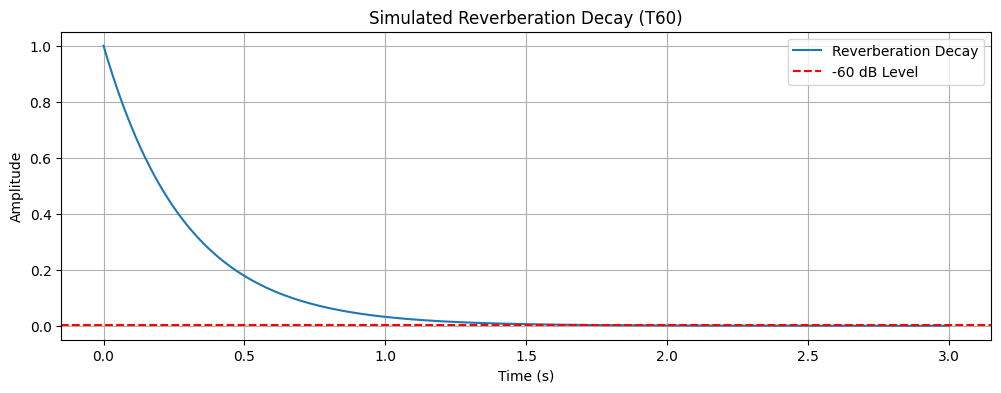

In [13]:
# Simulate a simple exponential decay to illustrate T60 reverberation time
initial_amplitude = 1.0
t = np.linspace(0, 3, 1000)  # 3 seconds duration

# T60 is the time for amplitude to decay by 60 dB (factor of 1/1000)
T60 = 2.0  # seconds (example value)
decay_curve = initial_amplitude * np.exp(-t * np.log(1000) / T60)

plt.figure(figsize=(12, 4))
plt.plot(t, decay_curve, label='Reverberation Decay')
plt.axhline(initial_amplitude / 1000, color='red', linestyle='--', label='-60 dB Level')
plt.title('Simulated Reverberation Decay (T60)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

### Beyond reverberation time

T60 says how *long* sound takes to die away, but not how the energy is distributed while it does. Two further measures fill that in, and you will meet them in any concert-hall report:

- **Clarity (C50, C80)** compares early-arriving energy with late energy. More early energy means crisper attacks and clearer detail; more late energy means a more blended, reverberant sound. C50 (a 50 ms cutoff) is used for speech, C80 (80 ms) for music.
- **Bass ratio (BR)** compares low-frequency reverberation with the mid range. A high BR sounds warm, or boomy; a low one sounds thin.

Neither measure is good or bad in itself. A hall built for late-Romantic orchestral repertoire and one built for spoken theatre should have different values, and both should be read alongside T60 rather than instead of it.

:::{note} Dig deeper: how clarity and bass ratio are calculated
:class: dropdown
To measure C50 or C80 you first need an impulse response for the room (for example from a sine sweep, a starter pistol, or a balloon pop). You can then calculate the clarity index following the ISO 3382 procedure. A positive Cx means the room has proportionally more early energy, so sounds have crisp attacks and good articulation. A negative Cx means more late energy, so the sound is more reverberant and blended. A very high C80 can make orchestral music sound dry; a very low C80 can make it muddy or indistinct.

Typical target ranges are approximate and depend on what the room is used for. For speech, C50 > 0 dB is generally good, and classrooms often aim for 4–8 dB. For music, C80 varies: large symphonic halls often sit around −2 to +1 dB (favouring richness), while chamber music, amplified pop, or opera that needs more clarity often aims for C80 above 0 up to a few dB. Values above about 3 dB can be very clear but may feel too dry for some orchestral repertoire.

C50 correlates with speech intelligibility indices (such as STI or RASTI); C80 correlates with the perceived clarity of musical detail.

The bass ratio is commonly computed from octave-band reverberation times (e.g., T60 or T20/T30), following Beranek:

- BR ≈ 1 (Beranek's recommendation): balanced low-frequency decay relative to the mids, neither boomy nor thin.
- BR > 1: relatively long low-frequency reverberation, which may be heard as warm or boomy.
- BR < 1: relatively short low-frequency reverberation, which may sound thin or lacking in bass presence.

Concert halls often aim near 1 (slightly above 1 can add warmth), while small rooms and speech spaces may prefer lower values.
:::

```{exercise} Measure your own room
:label: Measure your own room
Reverberation time is one of the few room properties you can measure with equipment you already own.

1. Pick two rooms that sound obviously different, such as a bathroom and a bedroom.
2. In each, start a voice recorder on your phone, stand near the middle, clap once, sharply, and let the room settle before stopping. A single hard clap approximates the impulse the formal method uses.
3. Open each recording in [Audacity](https://www.audacityteam.org/) or [Sonic Visualiser](https://www.sonicvisualiser.org/) and look at the waveform on a decibel scale. Find the moment of the clap and the moment the decay disappears into the noise floor.
4. You will almost certainly not get a clean 60 dB of decay before the noise floor swallows it, which is exactly why acousticians measure a smaller drop and extrapolate. Measure how long a 20 dB decay takes and multiply by three.

Compare the two numbers, then compare them to your ears. Does the room you called "live" have the longer figure? What does the shorter room do to speech, and what does the longer one do to fast music?
```


## Instrument acoustics

Room acoustics is a large field, and there are plenty of jobs for people who build and modify rooms in buildings. Far fewer people work on instrument acoustics. The scale is smaller, but most of the same principles apply, now turned to how musical instruments generate, shape, and radiate sound.

### Principles of instrument acoustics

The main physical principles are the *vibration source* and the instrument's *resonance*. The initial sound comes from vibrating elements such as strings (guitar, violin), air columns (flute, trumpet), membranes (drum), or solid bodies (xylophone). Most instruments then have resonating bodies—soundboards, tubes, shells—that amplify and colour the sound. The shape, size, and material of these bodies set the instrument's timbre and loudness.

The vibration source largely determines the *frequency range* of the instrument. Each instrument has a characteristic range of frequencies it can produce, fixed by its physical dimensions and construction.

```{image} figures/external/acoustics/01-fundamentels_instruments_big.jpg
:alt: Fundamentals of Instrument Acoustics
:width: 100%
```

*Figure: Fundamentals of Instrument Acoustics ([Credit: Sebastian Merchel](http://www.sebastianmerchel.de/)).*

Resonance also shapes *timbre* through the instrument's partials and overtones. Instruments rarely produce pure tones; they generate complex waves with many harmonics, and the relative strength of those harmonics gives each instrument its distinctive sound.

An instrument's *radiation pattern*—how it projects sound into the surrounding space—depends on its geometry and on playing technique.

:::: {grid} 1 1 2 3
::: {card}
:header: String instruments

When a string is plucked or bowed, it vibrates at its fundamental frequency and produces harmonics. The body of the instrument (such as a guitar or violin) amplifies these vibrations and shapes the sound. The material and construction of the body affect the instrument's tone and projection.
:::

::: {card}
:header: Wind instruments

Wind instruments produce sound by vibrating air columns. The length, shape, and material of the tube set the pitch and timbre. Opening and closing holes changes the effective length of the air column, allowing different notes to be played.
:::

::: {card}
:header: Percussion instruments

Percussion instruments generate sound through striking, shaking, or scraping. The vibration of membranes (drums) or solid bodies (bells, xylophones) creates complex waveforms. The size, tension, and material of the vibrating surface influence the pitch and timbre.
:::
::::


### Organology

Alongside acousticians, there is an academic field devoted to the study of musical instruments: *[organology](https://en.wikipedia.org/wiki/Organology)*. It was developed by (ethno)musicologists and researchers in instrument museums in the late 19th and early 20th century, out of the need to organise large collections of instruments.

The best-known organological system is the [Hornbostel–Sachs System](https://en.wikipedia.org/wiki/Hornbostel%E2%80%93Sachs), which classifies instruments by how they produce sound. The main categories are:

- **Idiophones**: Instruments that produce sound mainly through the vibration of their own material, without strings, membranes, or external air columns. Examples include xylophones, cymbals, and bells.
- **Membranophones**: Instruments that produce sound by vibrating a stretched membrane. Drums are the most common example, where the membrane is struck, rubbed, or otherwise excited.
- **Chordophones**: Instruments that produce sound by vibrating strings stretched between fixed points. This group includes violins, guitars, harps, and pianos.
- **Aerophones**: Instruments that produce sound by vibrating columns of air. Examples are flutes, trumpets, saxophones, and pipe organs.
- **Electrophones**: Instruments that produce sound mainly through electrical means. This includes synthesisers, electric guitars (when amplified), and theremins.

Each category divides further by how the sound is initiated (struck, plucked, bowed, blown, and so on), by the construction of the instrument, and by its acoustic properties. On a lighter note, Disney made an animated film called *Toot Whistle Plunk and Boom* in 1953 that plays with the differences between instruments:

<iframe width="560" height="315" src="https://www.youtube.com/embed/8iVf0pPHvjc?si=Q7N2xX4m8J1x2ZEL" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

:::{seealso} Further reading
- **Howard & Angus, *Acoustics and Psychoacoustics* (Focal Press)** — acoustics pitched for music and audio students. https://doi.org/10.4324/9781315716879
- **Rossing, Moore & Wheeler, *The Science of Sound*** — a classic, accessible acoustics textbook. https://www.pearson.com/en-us/subject-catalog/p/science-of-sound-the/P200000006977/9780805385656
- **Trevor Cox, *The Sound Book*** — a popular tour of acoustics and everyday sound. https://wwnorton.com/books/The-Sound-Book/
:::

:::{tip} Explore interactively
- [Falstad Fourier series applet](https://www.falstad.com/fourier/) — build waveforms from sine components.
- [Falstad Ripple Tank](https://www.falstad.com/ripple/) — see 2-D wave reflection, diffraction, and interference.
- [Chrome Music Lab: Harmonics](https://musiclab.chromeexperiments.com/Harmonics/) — hear the harmonic series.
:::

## Chapter summary

This chapter linked physical acoustics—waves, spectra, resonance, and rooms—to how instruments radiate sound and how we visualise and measure signals in time and frequency. With that in place, you can start to connect wave physics to what listeners actually hear.

## Questions

1. How do longitudinal versus transverse waves relate to sound in air versus waves on strings, and why does that matter for instruments?
2. How do frequency, amplitude, and phase each affect perception and measurement of musical signals?
3. What roles do room modes, reflections, and absorption play in perceived timbre and clarity in real spaces?
4. How does the Hornbostel–Sachs classification reflect different physical sound-production principles across cultures?
5. When using spectrograms or spectra for analysis, what trade-offs between time and frequency resolution should you keep in mind?
